# Phase 1 — Data Range Extension, Regime Segmentation, Honest Baselines

This notebook only calls `scaata` package functions and renders results — all logic lives in `scaata/` so it's reusable by later phases and covered by `tests/`.

Set `SMOKE_TEST = True` (default) for a fast end-to-end sanity check (~a few minutes). Set it to `False` for the real research run (all 9 tickers, all walk-forward folds, full 100k-timestep PPO training x 3 seeds) — that run will take substantially longer (likely hours), since it retrains a policy per fold.

In [1]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import pandas as pd

from scaata.config import ALL_TICKERS, START_DATE, END_DATE, FEATURE_COLUMNS, DEFAULT_SEEDS, PPO_TOTAL_TIMESTEPS
from scaata.data.loaders import load_market_data
from scaata.features.technical import add_features
from scaata.regimes.detector import threshold_regime_labels, hmm_regime_labels, regime_label_agreement
from scaata.evaluation.walkforward import generate_folds, assert_no_overlap, split_fold
from scaata.evaluation.phase1_pipeline import (
    run_phase1_backtest, summarize_results, compare_methods_across_tickers, significance_report,
)
from scaata.evaluation.regime_report import era_comparison_report
from scaata.evaluation.plots import (
    plot_regime_equity_curve, plot_macro_event_annotations,
    plot_regime_performance_comparison, plot_drawdown, plot_returns_distribution,
)

SMOKE_TEST = True

if SMOKE_TEST:
    TICKERS = ALL_TICKERS[:3]
    PPO_TIMESTEPS = 2000
    SEEDS = [0]
    MAX_FOLDS = 2
else:
    TICKERS = ALL_TICKERS
    PPO_TIMESTEPS = PPO_TOTAL_TIMESTEPS
    SEEDS = DEFAULT_SEEDS
    MAX_FOLDS = None

print(f"SMOKE_TEST={SMOKE_TEST} | tickers={TICKERS} | ppo_timesteps={PPO_TIMESTEPS} | seeds={SEEDS}")

SMOKE_TEST=True | tickers=['AAPL', 'MSFT', 'GOOGL'] | ppo_timesteps=2000 | seeds=[0]


## 1. Data: 2020-01-01 to 2026-07-19, including non-survivor tickers

In [2]:
raw_df = load_market_data(TICKERS, START_DATE, END_DATE, use_cache=True)
print(f"raw shape: {raw_df.shape}, tickers: {raw_df['Ticker'].unique()}")

featured_df = add_features(raw_df)
print(f"featured shape: {featured_df.shape}")

raw shape: (4929, 6), tickers: <ArrowStringArray>
['AAPL', 'MSFT', 'GOOGL']
Length: 3, dtype: str
featured shape: (4782, 13)


## 2. Regime / stress-zone segmentation (causal)

In [3]:
threshold_labels = threshold_regime_labels(featured_df)
print(threshold_labels['regime'].value_counts())

# HMM cross-check, fit on the Phase-1 train window only
train_slice = featured_df[featured_df.index < '2024-01-01']
hmm_labels = hmm_regime_labels(train_slice, featured_df)

merged = threshold_labels.join(hmm_labels[['hmm_state', 'hmm_vol_regime']])
kappa = regime_label_agreement(merged['vol_regime'], merged['hmm_vol_regime'])
print(f"\nCohen's kappa (threshold vs HMM vol-regime agreement): {kappa:.3f}")
print("Sanity check: if this is near 0, the threshold buckets may be arbitrary — investigate before trusting them.")

regime
calm_bull        3932
volatile_bull     324
bear              311
crisis            215
Name: count, dtype: int64



Cohen's kappa (threshold vs HMM vol-regime agreement): 0.330
Sanity check: if this is near 0, the threshold buckets may be arbitrary — investigate before trusting them.


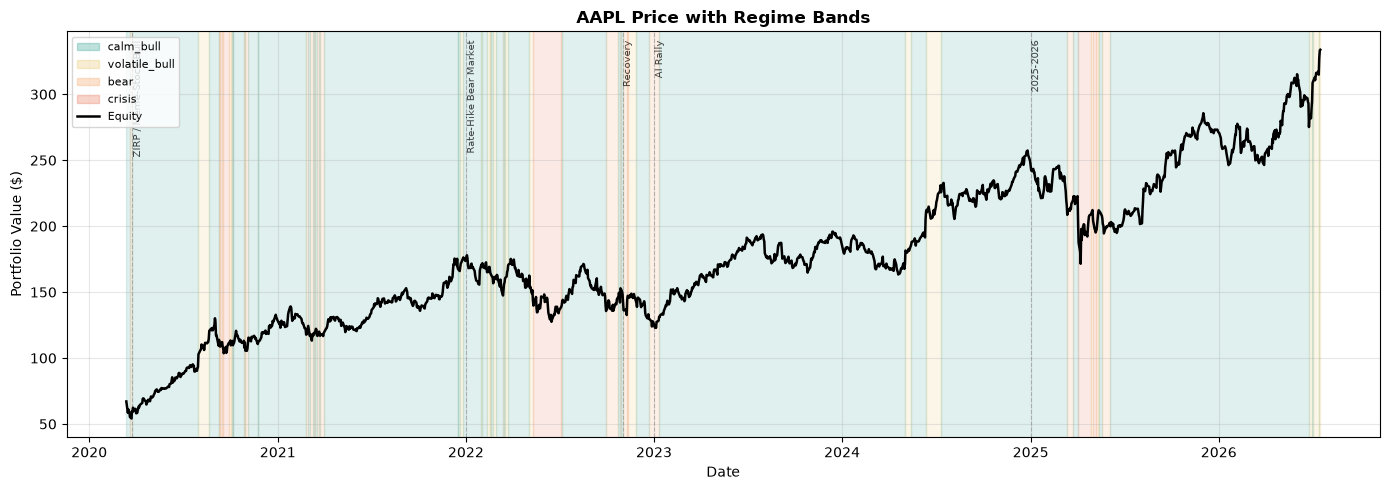

In [4]:
# Visual sanity check: does the detector actually flag the known COVID crash / 2022 bear market?
sample_ticker = TICKERS[0]
sample = threshold_labels[threshold_labels['Ticker'] == sample_ticker]

fig, ax = plt.subplots(figsize=(14, 5))
ax = plot_regime_equity_curve(sample.index, sample['Close'].values, sample['regime'], f"{sample_ticker} Price with Regime Bands", ax=ax)
plot_macro_event_annotations(sample.index, ax)
plt.tight_layout()
plt.show()

## 3. Walk-forward folds (replaces the single 80/20 split)

In [5]:
folds = generate_folds(START_DATE, END_DATE)
assert_no_overlap(folds)
if MAX_FOLDS:
    folds = folds[:MAX_FOLDS]

for f in folds:
    print(f"fold {f.fold_id}: train [{f.train_start.date()} - {f.train_end.date()}] -> test [{f.test_start.date()} - {f.test_end.date()}]")

fold 0: train [2020-01-01 - 2021-12-31] -> test [2022-01-01 - 2022-06-30]
fold 1: train [2020-07-01 - 2022-06-30] -> test [2022-07-01 - 2022-12-31]


## 4. Baselines per fold x ticker x seed: buy-and-hold, rule-based, PPO

In [6]:
all_seed_results = {}
for seed in SEEDS:
    print(f"--- seed {seed} ---")
    all_seed_results[seed] = run_phase1_backtest(
        TICKERS, featured_df, folds, feature_columns=FEATURE_COLUMNS, ppo_timesteps=PPO_TIMESTEPS, seed=seed,
    )

results = all_seed_results[SEEDS[0]]
print(f"\n{len(results)} (ticker, fold) results for seed {SEEDS[0]}")

--- seed 0 ---



6 (ticker, fold) results for seed 0


## 5. Per-regime metrics, bootstrap CIs, cross-ticker significance

In [7]:
for method in ['buy_and_hold', 'rule_based', 'ppo']:
    summary = summarize_results(results, method)
    print(f"\n=== {method} — per-regime metrics pooled across tickers/folds ===")
    print(summary['pooled_table'].groupby(level=0)[['sharpe', 'sortino', 'max_drawdown', 'turnover']].mean())


=== buy_and_hold — per-regime metrics pooled across tickers/folds ===
                 sharpe    sortino max_drawdown turnover
ALL            -0.89921  -1.483126    -0.283896      0.0
bear            0.60216    1.25515    -0.112102      0.0
calm_bull     -2.050224  -3.200157    -0.284747      0.0
crisis         6.340911  22.600121    -0.014568      0.0
volatile_bull  0.896682  -0.865082    -0.020988      0.0



=== rule_based — per-regime metrics pooled across tickers/folds ===
                 sharpe   sortino max_drawdown  turnover
ALL           -1.197507 -0.684812    -0.095173  0.598335
bear                NaN       NaN          0.0  0.966452
calm_bull     -1.594159 -1.142104    -0.095173  0.401689
crisis              NaN       NaN          0.0       1.0
volatile_bull  7.198259       NaN          0.0       1.0



=== ppo — per-regime metrics pooled across tickers/folds ===
                 sharpe    sortino max_drawdown  turnover
ALL           -1.409473  -1.692185    -0.260312  0.634308
bear          -3.206859  -4.015319    -0.175521  0.731525
calm_bull     -0.832462  -1.035768    -0.147339  0.605789
crisis         2.608149  19.639201     -0.03377      0.25
volatile_bull -3.943109 -10.486081    -0.009353       0.0


In [8]:
cmp_df = compare_methods_across_tickers(results)
print(cmp_df)

sig = significance_report(cmp_df)
print("\nPaired Wilcoxon (PPO vs baselines, across tickers/folds):")
for k, v in sig.items():
    print(f"  {k}: {v}")

  ticker  fold_id  buy_and_hold  rule_based       ppo
0   AAPL        0     -1.443693   -1.594306 -1.054185
1   MSFT        0     -1.327354   -1.930009 -2.383380
2  GOOGL        0     -1.336120   -1.943367 -1.162204
3   AAPL        1     -0.181925   -0.737824 -1.453636
4   MSFT        1     -0.242608    0.057829 -2.032231
5  GOOGL        1     -0.863563   -1.037363 -0.371200

Paired Wilcoxon (PPO vs baselines, across tickers/folds):
  ppo_vs_buy_and_hold: {'statistic': 6.0, 'p_value': 0.4375, 'n': 6, 'note': ''}
  ppo_vs_rule_based: {'statistic': 10.0, 'p_value': 1.0, 'n': 6, 'note': ''}


In [9]:
if len(SEEDS) > 1:
    from scaata.evaluation.stats import across_seed_summary
    for ticker_fold in set((r.ticker, r.fold_id) for r in results):
        seed_sharpes = []
        for seed in SEEDS:
            match = [r for r in all_seed_results[seed] if (r.ticker, r.fold_id) == ticker_fold]
            if match:
                from scaata.evaluation.metrics import regime_metrics_table
                table = regime_metrics_table(match[0].equity['ppo'], match[0].actions['ppo'], match[0].regimes)
                seed_sharpes.append(table.loc['ALL', 'sharpe'])
        print(ticker_fold, across_seed_summary(seed_sharpes))
else:
    print("Only 1 seed run (SMOKE_TEST default) — set SEEDS to multiple values for real seed-variance reporting.")

Only 1 seed run (SMOKE_TEST default) — set SEEDS to multiple values for real seed-variance reporting.


## 6. 2020-era vs 2026-era comparison (the core Phase 1 deliverable)

2020-era-fold table:
              sharpe   sortino max_drawdown total_return n_days small_sample  \
ALL       -1.054185 -1.572034    -0.261278    -0.190692    123        False   
calm_bull -0.817459 -1.341891    -0.149065    -0.104472     88        False   
bear      -2.142337 -2.831245    -0.147281    -0.090564     25         True   
crisis    -0.120623  -0.16836     -0.08059    -0.006284     10         True   

           turnover  
ALL        0.894309  
calm_bull  0.886364  
bear           0.88  
crisis          1.0  

2026-era-fold table:
                  sharpe    sortino max_drawdown total_return n_days  \
ALL             -0.3712  -0.509964    -0.259581    -0.087971    126   
calm_bull     -0.118267  -0.163353    -0.184791    -0.024559     73   
bear          -3.860166  -4.462235    -0.218307    -0.196225     40   
crisis         9.818756  39.446761    -0.017773     0.178953     10   
volatile_bull -3.943109 -10.486081     -0.02806    -0.013318      3   

              small_sa

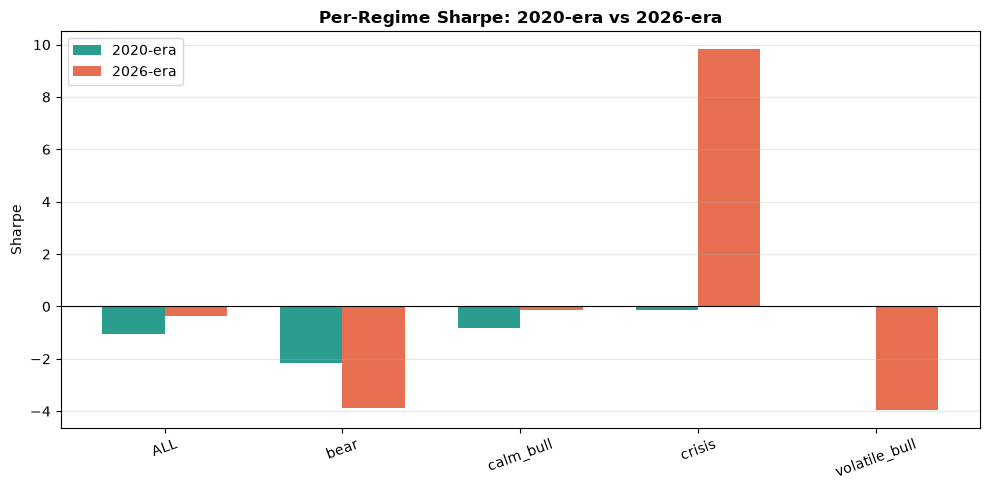

In [10]:
early_result = results[0]
late_result = results[-1]

era_report = era_comparison_report(
    early_result.equity['ppo'], early_result.actions['ppo'], early_result.regimes,
    late_result.equity['ppo'], late_result.actions['ppo'], late_result.regimes,
)
print('2020-era-fold table:\n', era_report['table_2020'])
print('\n2026-era-fold table:\n', era_report['table_2026'])
print('\nSharpe bootstrap CI (2020-era fold):', era_report['sharpe_ci_2020'])
print('Sharpe bootstrap CI (2026-era fold):', era_report['sharpe_ci_2026'])

fig = plot_regime_performance_comparison(era_report['table_2020'], era_report['table_2026'], metric='sharpe')
plt.show()

## 7. Supporting graphs for the last fold's PPO run

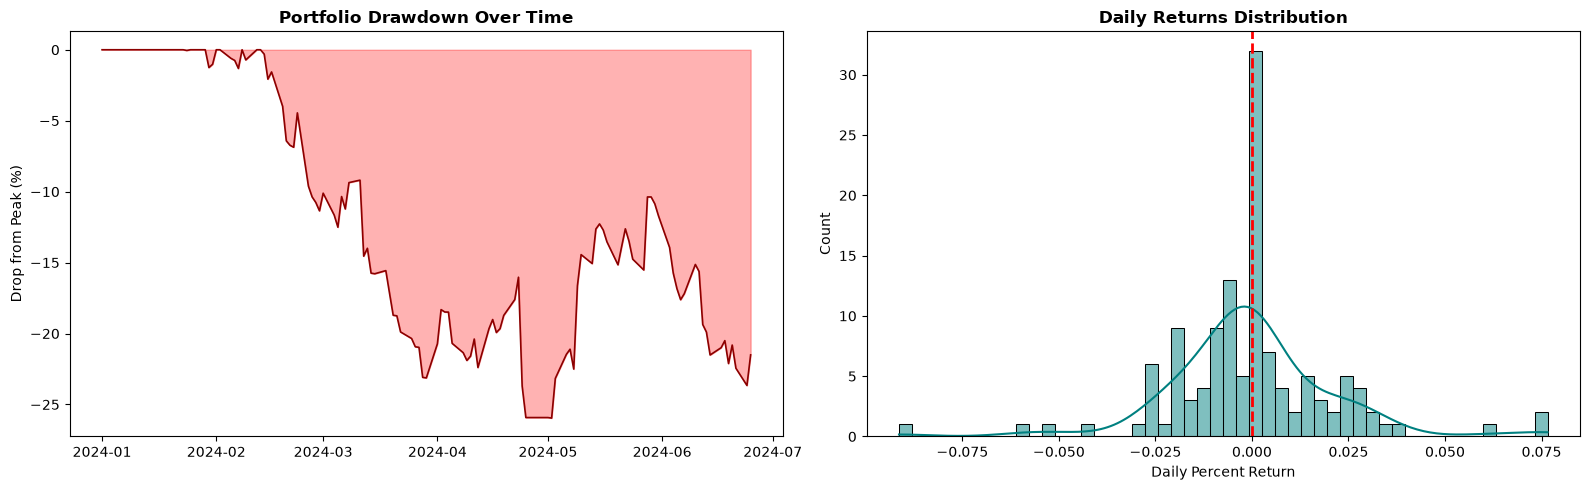

In [11]:
last = results[-1]
equity = last.equity['ppo']
dates = pd.date_range(start='2024-01-01', periods=len(equity), freq='B')  # placeholder axis length-matched to equity

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_drawdown(dates, equity, ax=axes[0])
plot_returns_distribution(equity, ax=axes[1])
plt.tight_layout()
plt.show()

## Done criteria for this phase
- Regime bands above visually align with the known COVID crash / 2022 bear market.
- Cohen's kappa between threshold and HMM regime labels is meaningfully above 0 (methods agree more than chance).
- Walk-forward folds have zero train/test overlap (enforced by `assert_no_overlap`, also covered by `tests/test_walkforward.py`).
- Bootstrap CIs and the Wilcoxon test run without error and are wide/inconclusive at `SMOKE_TEST` scale (expected — real conclusions require the full run with more tickers, folds, and seeds).